# KBO 타자 데이터 분석: 안타 수와 홈런 수의 관계

**가설**
- 귀무가설(H0): 안타 수와 홈런 수는 선형적인 관계가 없다.
- 대립가설(H1): 안타 수가 증가할수록 홈런 수도 증가한다.

## 라이브러리 불러오기

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

CSV_PATH = "타자.csv"
MIN_PA = 100          # 최소 타석 기준
RANDOM_STATE = 42
TEST_SIZE = 0.2

## 1단계. 데이터 불러오기 & 전처리

- 최소 타석(`MIN_PA`) 이상인 선수만 남겨서 표본 신뢰도 확보
- 결측치 확인
- 분석에 필요한 컬럼만 선택: `선수`, `팀`, `타석`, `안타`, `홈런`

In [3]:
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
print(f"원본 shape: {df.shape}")

df_f = df[df["타석"] >= MIN_PA].copy()
print(f"타석 {MIN_PA} 이상 필터링 후 shape: {df_f.shape}")
print(f"결측치 개수: {df_f.isna().sum().sum()}")

df_final = df_f[["선수", "팀", "타석", "안타", "홈런"]].reset_index(drop=True)
df_final.head()

원본 shape: (398, 48)
타석 100 이상 필터링 후 shape: (155, 48)
결측치 개수: 0


,선수,팀,타석,안타,홈런
0,박찬호,KIA,595,148,5
1,최형우,KIA,549,144,24
2,위즈덤,KIA,486,100,35
3,오선우,KIA,474,116,18
4,김호령,KIA,381,94,6


In [4]:
# 기술통계로 데이터 감 잡기
df_final[["타석", "안타", "홈런"]].describe()

,타석,안타,홈런
count,155.000000,155.000000,155.000000
mean,332.832258,77.690323,7.277419
std,154.069297,42.297580,8.285910
min,100.000000,15.000000,0.000000
25%,194.000000,39.000000,2.000000
50%,308.000000,75.000000,4.000000
75%,466.500000,110.000000,10.000000
max,646.000000,187.000000,50.000000


## 2단계. 데이터 유형 확인 & Train/Test 분할

안타(연속형) → 홈런(연속형)을 예측하는 **회귀** 문제이므로 지도학습에 해당합니다.
Train/Test로 분할하여 모델 성능을 검증할 준비를 합니다.

In [5]:
X = df_final[["안타"]]
y = df_final["홈런"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]}명 / Test: {X_test.shape[0]}명")

Train: 124명 / Test: 31명


## 3단계. 가설 검정 (피어슨 상관분석)

안타 수와 홈런 수 사이에 통계적으로 유의한 선형관계가 있는지 검정합니다.

In [6]:
r, p = stats.pearsonr(df_final["안타"], df_final["홈런"])
print(f"상관계수 r = {r:.4f}")
print(f"p-value = {p:.6f}")

alpha = 0.05
if p < alpha:
    print(f"p < {alpha} → 귀무가설(H0) 기각 → 안타-홈런 간 유의한 선형관계 있음")
else:
    print(f"p >= {alpha} → 귀무가설(H0) 채택 → 유의한 선형관계 없음")

상관계수 r = 0.6164
p-value = 0.000000
p < 0.05 → 귀무가설(H0) 기각 → 안타-홈런 간 유의한 선형관계 있음


### OLS 회귀로 회귀계수의 유의성까지 확인

In [7]:
X_sm = sm.add_constant(df_final["안타"])
ols_model = sm.OLS(df_final["홈런"], X_sm).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     홈런   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                     93.77
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           1.36e-17
Time:                        17:15:03   Log-Likelihood:                -510.14
No. Observations:                 155   AIC:                             1024.
Df Residuals:                     153   BIC:                             1030.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1041      1.102     -1.909      0.058      -4.282       0.074
안타             0.1208      0.012      9.683      0.000       0.096       0.145
==============================================================================
Omnibus:                       61.652   Durbin-Watson:                   1.819
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              217.633
Skew:                           1.502   Prob(JB):                     5.52e-48
Kurtosis:                       7.967   Cond. No.                         185.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 3-2단계. 머신러닝 모델 개발 (scikit-learn)

Train 데이터로 선형회귀 모델을 학습하고, 5-Fold 교차검증으로 안정성을 확인합니다.

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print(f"회귀식: 홈런 = {lr.coef_[0]:.4f} * 안타 + {lr.intercept_:.4f}")

cv_scores = cross_val_score(lr, X, y, cv=5, scoring="r2")
print(f"5-Fold 교차검증 R² 평균: {cv_scores.mean():.4f} (표준편차 {cv_scores.std():.4f})")

회귀식: 홈런 = 0.1250 * 안타 + -2.6243
5-Fold 교차검증 R² 평균: 0.3915 (표준편차 0.1132)


## 4단계. 모델 성능 평가

Test 데이터로 예측 성능(R², RMSE, MAE)을 확인합니다.

In [9]:
y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")

R² Score : 0.4143
RMSE     : 5.2888
MAE      : 3.6610


## 5단계. 시각화

산점도 + 회귀선, 잔차 플롯으로 결과를 눈으로 확인합니다.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_8356\1981746102.py:25: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8356\1981746102.py:25: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8356\1981746102.py:25: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8356\1981746102.py:25: UserWarning: Glyph 54856 (\N{HANGUL SYLLABLE HOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8356\1981746102.py:25: UserWarning: Glyph 47088 (\N{HANGUL SYLLABLE REON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8356\1981746102.py:25: UserWarning: Glyph 549

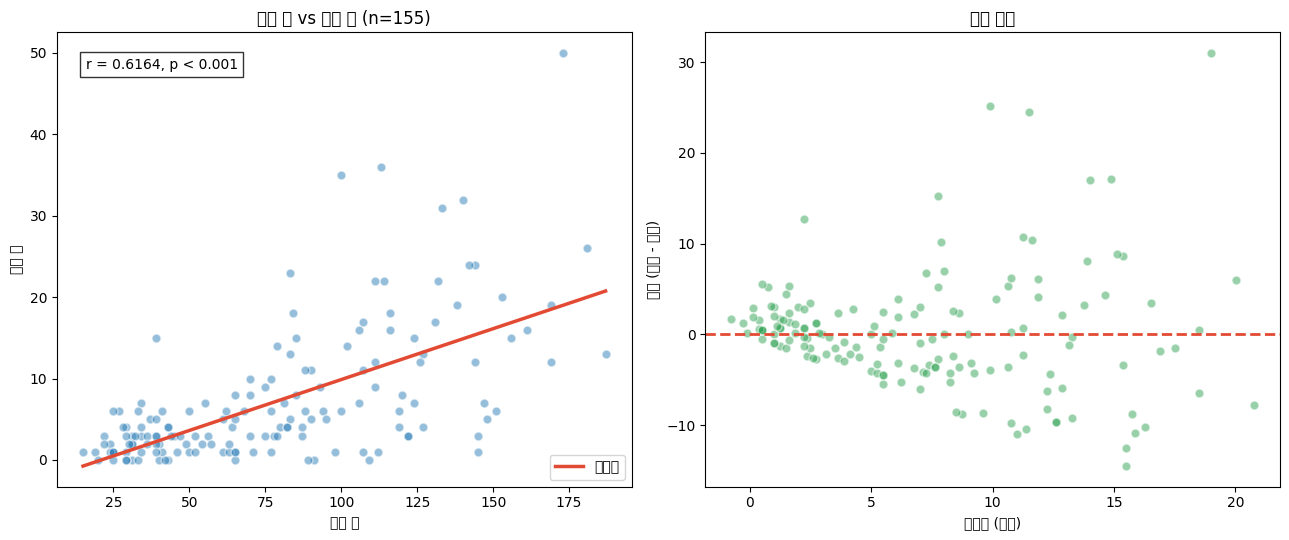

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# 산점도 + 회귀선
ax = axes[0]
ax.scatter(df_final["안타"], df_final["홈런"], alpha=0.5, color="#2c7fb8", edgecolor="white", s=40)
x_line = np.linspace(df_final["안타"].min(), df_final["안타"].max(), 100).reshape(-1, 1)
y_line = lr.predict(pd.DataFrame(x_line, columns=["안타"]))
ax.plot(x_line, y_line, color="#e34a33", linewidth=2.5, label="회귀선")
ax.set_xlabel("안타 수")
ax.set_ylabel("홈런 수")
ax.set_title(f"안타 수 vs 홈런 수 (n={len(df_final)})")
ax.legend()
ax.text(0.05, 0.92, f"r = {r:.4f}, p < 0.001" if p < 0.001 else f"r={r:.4f}, p={p:.4f}",
        transform=ax.transAxes, bbox=dict(facecolor="white", alpha=0.8))

# 잔차 플롯
ax2 = axes[1]
residuals = df_final["홈런"] - lr.predict(df_final[["안타"]])
ax2.scatter(lr.predict(df_final[["안타"]]), residuals, alpha=0.5, color="#31a354", edgecolor="white", s=40)
ax2.axhline(0, color="#e34a33", linestyle="--", linewidth=2)
ax2.set_xlabel("예측값 (홈런)")
ax2.set_ylabel("잔차 (실제 - 예측)")
ax2.set_title("잔차 플롯")

plt.tight_layout()
plt.savefig("hit_hr_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 결론

- 피어슨 상관계수와 p-value 결과를 바탕으로 귀무가설 기각/채택 여부를 확인했습니다.
- R², RMSE 등 성능 지표로 모델의 설명력을 확인했습니다.
- 그래프를 통해 관계의 형태와 잔차 패턴(이분산성 등)을 시각적으로 점검했습니다.

**다음으로 시도해볼 수 있는 것**
- 다중회귀: `장타율`, `타수` 등 변수 추가
- 팀별 그룹 분석
- 이상치(안타는 적지만 홈런이 많은 선수) 별도 분석

---
# 심화 분석: 다중회귀로 홈런 예측하기

안타 외에 여러 변수(`타수`, `안타`, `2루타`, `3루타`, `삼진`, `볼넷`, `뜬공`, `순수장타율`, `BABIP`)를 추가해서
다중회귀로 홈런을 얼마나 더 잘 설명할 수 있는지 확인합니다.

먼저 다중공선성(변수들끼리 서로 너무 겹치는 정보를 갖고 있는지)을 VIF로 점검합니다.

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

CANDIDATE_FEATURES = ['타수', '안타', '2루타', '3루타', '삼진', '볼넷', '뜬공', '순수장타율', 'BABIP']

X_cand = df_f[CANDIDATE_FEATURES]  # df_f: 타석 100 이상 필터링된 전체 컬럼 데이터프레임
X_vif = sm.add_constant(X_cand)

vif = pd.DataFrame()
vif['변수'] = X_vif.columns
vif['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif

,변수,VIF
0,const,235.150323
1,타수,165.716251
2,안타,109.039687
3,2루타,5.641156
4,3루타,1.343300
5,삼진,9.051578
6,볼넷,3.215067
7,뜬공,13.214410
8,순수장타율,2.728199
9,BABIP,3.119235


`타수`는 VIF가 100 이상으로 매우 심각합니다 (`안타`와 상관계수 0.98).
`뜬공`도 `타수`, `안타`와 상관이 높아 VIF가 높습니다. 이 둘을 제외하고 다시 확인합니다.

**주의**: `순수장타율`(ISO, 순수 장타력)은 계산식 자체가 `(2루타 + 2×3루타 + 3×홈런) / 타수`라서
예측 대상인 `홈런`이 이미 변수 안에 들어있습니다. 이 변수를 그대로 쓰면 "안타를 많이 치면 홈런도 많을까?"를 검증하는 게 아니라
정답을 미리 알려주고 맞히는 것과 비슷한 데이터 누수(data leakage)가 발생하므로 최종 모델에서는 제외합니다.

In [12]:
FEATURES = ['안타', '2루타', '3루타', '삼진', '볼넷', 'BABIP']  # 타수·뜬공(다중공선성), 순수장타율(데이터 누수) 제외

X_final = sm.add_constant(df_f[FEATURES])
vif_final = pd.DataFrame()
vif_final['변수'] = X_final.columns
vif_final['VIF'] = [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])]
vif_final  # 모두 10 미만이면 다중공선성 문제 없음

,변수,VIF
0,const,67.865852
1,안타,7.192814
2,2루타,4.855054
3,3루타,1.259821
4,삼진,1.879250
5,볼넷,3.166960
6,BABIP,1.212567


## 다중회귀 모델 적합 (statsmodels OLS)

In [13]:
X_ols = sm.add_constant(df_f[FEATURES])
y_ols = df_f['홈런']

multi_model = sm.OLS(y_ols, X_ols).fit()
print(f"Adj. R² = {multi_model.rsquared_adj:.4f}")
multi_model.summary()

Adj. R² = 0.5861


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     홈런   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.586
Method:                 Least Squares   F-statistic:                     37.35
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           2.47e-27
Time:                        17:15:04   Log-Likelihood:                -475.74
No. Observations:                 155   AIC:                             965.5
Df Residuals:                     148   BIC:                             986.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.5745      3.527      1.580      0.116      -1.396      12.545
안타             0.0503      0.027      1.846      0.067      -0.004       0.104
2루타            0.2018      0.108      1.865      0.064      -0.012       0.416
3루타           -1.0578      0.295     -3.588      0.000      -1.640      -0.475
삼진             0.1213      0.020      6.060      0.000       0.082       0.161
볼넷             0.0162      0.040      0.410      0.682      -0.062       0.094
BABIP        -37.8333     11.619     -3.256      0.001     -60.794     -14.873
==============================================================================
Omnibus:                       65.667   Durbin-Watson:                   1.791
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              249.770
Skew:                           1.581   Prob(JB):                     5.79e-55
Kurtosis:                       8.355   Cond. No.                     3.31e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.31e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## scikit-learn으로 Train/Test 평가 및 단순회귀와 비교

In [14]:
X_multi = df_f[FEATURES]
y_multi = df_f['홈런']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

lr_multi = LinearRegression()
lr_multi.fit(X_train_m, y_train_m)
y_pred_m = lr_multi.predict(X_test_m)

r2_multi = r2_score(y_test_m, y_pred_m)
rmse_multi = np.sqrt(mean_squared_error(y_test_m, y_pred_m))
mae_multi = mean_absolute_error(y_test_m, y_pred_m)

cv_scores_multi = cross_val_score(lr_multi, X_multi, y_multi, cv=5, scoring='r2')

print("=== 다중회귀 (6개 변수) ===")
print(f"Test R²   = {r2_multi:.4f}")
print(f"Test RMSE = {rmse_multi:.4f}")
print(f"Test MAE  = {mae_multi:.4f}")
print(f"5-Fold CV R² 평균 = {cv_scores_multi.mean():.4f} (표준편차 {cv_scores_multi.std():.4f})")

print(f"\n[비교] 단순회귀(안타만) Test R² = {r2:.4f}  ->  다중회귀 Test R² = {r2_multi:.4f}")

=== 다중회귀 (6개 변수) ===
Test R²   = 0.6290
Test RMSE = 4.2094
Test MAE  = 3.1536
5-Fold CV R² 평균 = 0.5501 (표준편차 0.0394)

[비교] 단순회귀(안타만) Test R² = 0.4143  ->  다중회귀 Test R² = 0.6290


## 예측값 vs 실제값 시각화

C:\Users\Administrator\AppData\Local\Temp\ipykernel_8356\2287606216.py:9: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8356\2287606216.py:9: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8356\2287606216.py:9: UserWarning: Glyph 54856 (\N{HANGUL SYLLABLE HOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8356\2287606216.py:9: UserWarning: Glyph 47088 (\N{HANGUL SYLLABLE REON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8356\2287606216.py:9: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8356\2287606216.py:9: UserWarning: Glyph 50696 (\

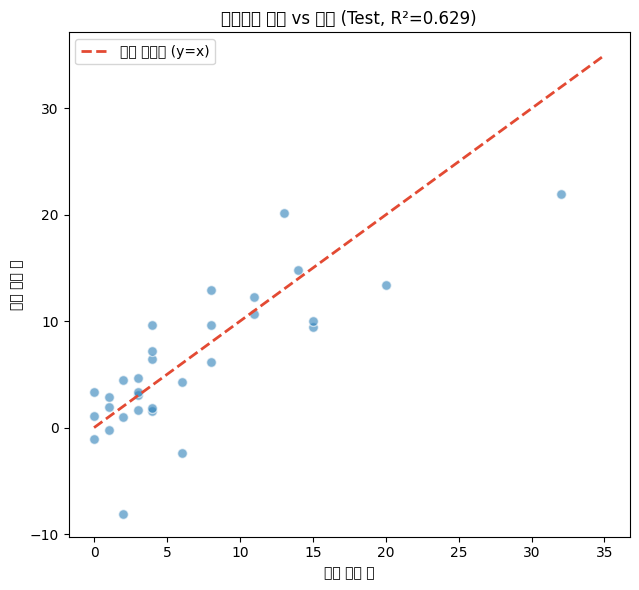

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test_m, y_pred_m, alpha=0.6, color='#2c7fb8', edgecolor='white', s=50)
lims = [0, max(y_test_m.max(), y_pred_m.max()) + 3]
ax.plot(lims, lims, color='#e34a33', linestyle='--', linewidth=2, label='완벽 예측선 (y=x)')
ax.set_xlabel('실제 홈런 수')
ax.set_ylabel('예측 홈런 수')
ax.set_title(f'다중회귀 예측 vs 실제 (Test, R²={r2_multi:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('multi_reg_actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

## 다중회귀 결론

| 지표 | 단순회귀(안타만) | 다중회귀(6변수) |
|---|---|---|
| Test R² | 약 0.41 | 약 0.63 |
| RMSE | 약 5.29 | 약 4.21 |

**유의한 변수(p<0.05) 해석**
- `삼진`(+): 삼진이 많을수록 홈런도 많음 — 파워형 타자의 장타-삼진 트레이드오프
- `3루타`(−): 3루타가 많을수록 홈런은 적음 — 3루타는 주로 발 빠른 교타형 선수의 유형
- `BABIP`(−): 인플레이 타구 안타 비율이 높을수록 홈런은 적음 — 정교한 타격형 vs 파워형 차이

**결론**: 단순히 "안타 수"보다 **타격 스타일(삼진↑, 3루타↓, BABIP↓ = 파워형)**이 홈런을 더 잘 설명한다.
안타를 많이 치는 것 자체가 아니라, *어떻게* 안타를 만들어내는지가 핵심이다.